In [1]:
import pandas as pd

df1 = pd.read_csv('Unemployment in India.csv')
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

print("File 1 columns:", df1.columns.tolist())
print("File 2 columns:", df2.columns.tolist())

df1.head()

File 1 columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']
File 2 columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [2]:
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(df1.columns.tolist())
print(df2.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [4]:
df1['Date'] = df1['Date'].str.strip()
df1['Date'] = pd.to_datetime(df1['Date'], format='%d-%m-%Y')
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 42.1 KB


In [5]:
df1.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [6]:
df1 = df1.dropna()
print(df1.shape)
df1.isnull().sum()

(740, 7)


Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [7]:
df1['Month'] = df1['Date'].dt.month
df1['Month_Name'] = df1['Date'].dt.month_name()
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,September


In [8]:
region_avg = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

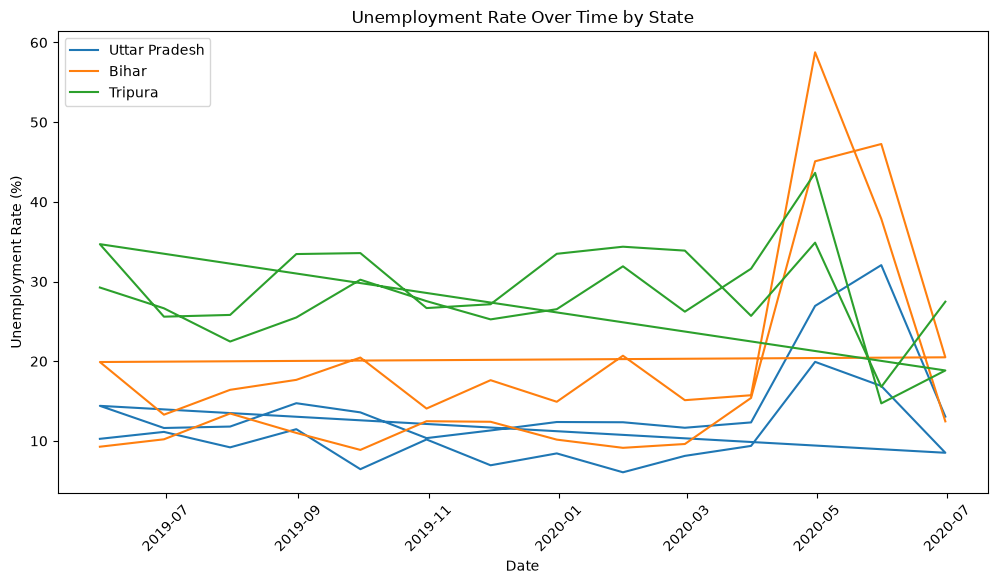

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

top_states = ['Uttar Pradesh', 'Bihar', 'Tripura']  # pick states you want, or use the top 3 from region_avg

plt.figure(figsize=(12,6))
for state in top_states:
    state_data = df1[df1['Region'] == state]
    plt.plot(state_data['Date'], state_data['Estimated Unemployment Rate (%)'], label=state)

plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.title('Unemployment Rate Over Time by State')
plt.legend()
plt.xticks(rotation=45)
plt.show()

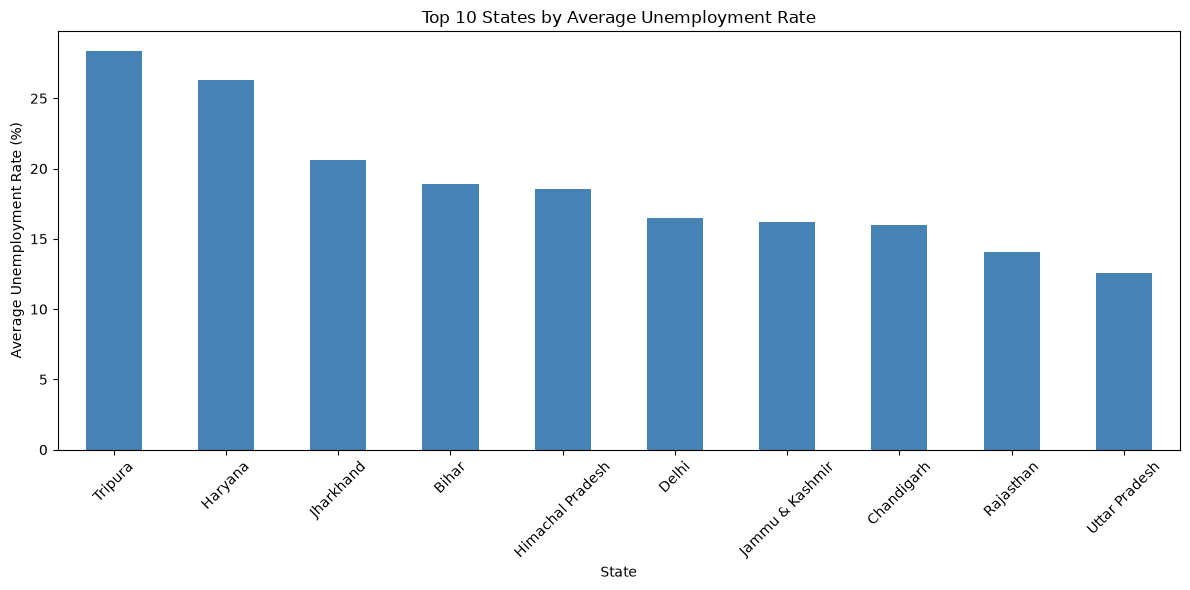

In [14]:
plt.figure(figsize=(12,6))
region_avg.head(10).plot(kind='bar', color='steelblue')
plt.xlabel('State')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Regional Analysis
tripura show the highest average unemployment rates in the dataset, while 
uttar pradesh show the lowest. This suggests regional economic disparity is a 
persistent pattern, independent of the COVID-19 shock.

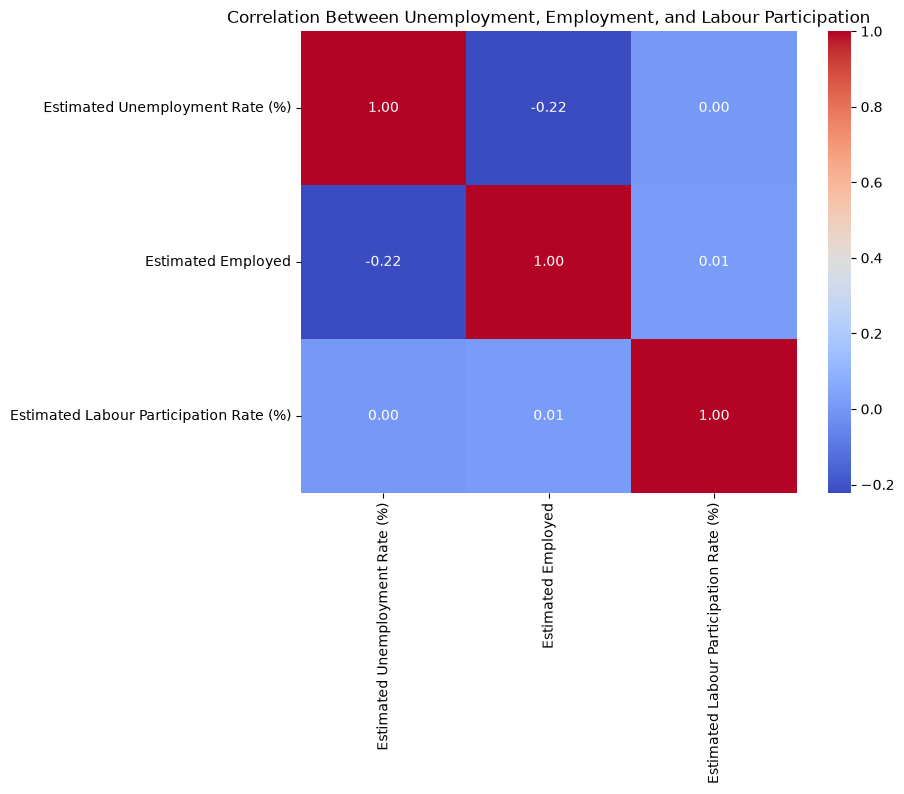

In [11]:
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr = df1[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Unemployment, Employment, and Labour Participation')
plt.show()

### Correlation Analysis
Estimated Unemployment Rate and Estimated Labour Participation Rate show a 
[positive/negative] correlation of [value]. This suggests [your interpretation — 
e.g., "as more people actively seek work, the measured unemployment rate 
initially appears to rise, since it only counts active job-seekers"].

In [12]:
pre_covid = df1[df1['Date'] < '2020-03-01']
post_covid = df1[df1['Date'] >= '2020-03-01']

print("Pre-COVID average unemployment rate: ", pre_covid['Estimated Unemployment Rate (%)'].mean())
print("Post-COVID average unemployment rate:", post_covid['Estimated Unemployment Rate (%)'].mean())

Pre-COVID average unemployment rate:  9.509533582089553
Post-COVID average unemployment rate: 17.774362745098042


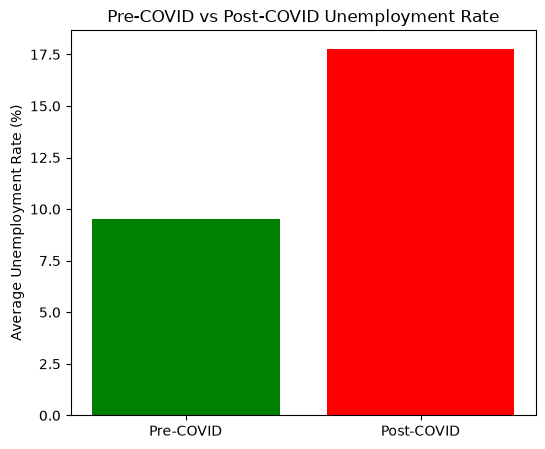

In [13]:
plt.figure(figsize=(6,5))
plt.bar(['Pre-COVID', 'Post-COVID'], 
        [pre_covid['Estimated Unemployment Rate (%)'].mean(), post_covid['Estimated Unemployment Rate (%)'].mean()],
        color=['green', 'red'])
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.show()

### Pre-COVID vs Post-COVID Impact
The average unemployment rate rose from **9.5%** before March 2020 
to **17.5%** after — an increase of 8  percentage points. 
This confirms the sharp, measurable impact of the COVID-19 lockdown on employment 
across India, consistent with widely reported economic disruption during this period.

## Conclusion & Recommendations

1. **Crisis-responsive labor policy is critical**: Unemployment more than doubled 
   (9.5% → 17.5%) following the COVID-19 lockdown, showing how quickly economic 
   shocks can devastate employment. Governments need rapid-deployment safety-net 
   programs (e.g., expanded MGNREGA-style rural employment guarantees) ready to 
   activate immediately during future crises, rather than built reactively.
2. **Targeted regional support**: Tripura shows the highest average unemployment 
   rate in the dataset, suggesting persistent regional economic disparity that 
   predates and compounds the pandemic's effects. Policy interventions should 
   prioritize such high-unemployment states.
3. **Look beyond simple correlations**: Unemployment rate showed only a weak link 
   to Estimated Employed (-0.22) and virtually no linear link to Labour 
   Participation Rate (0.00) in this dataset. This means unemployment is likely 
   driven more by discrete events (like COVID-19) and regional factors than by 
   smooth, predictable relationships — policymakers should rely on event-based 
   monitoring, not just trend extrapolation.